# Energy load

Electricity load has strong, *layered* seasonality — a daily usage rhythm nested inside a weekly one — plus consumer-driven shape variation. `EnergyLoadGenerator` reproduces these multi-seasonal profiles for grid-demand forecasting.

::: {.callout-note}
## The model

$$y_t = \text{base} + d(t) + w(t) + a(t) + \beta\,|T_t - T_{\text{base}}| + \varepsilon_t$$

The series combines daily and weekly cycles with a load shape and noise appropriate to `load_type` — `residential` (sharp morning and evening peaks) or `industrial` (flatter, weekday-driven). The overlapping periods make it a good test of multi-seasonal models.
:::

In [ ]:
import polars as pl
import matplotlib.pyplot as plt

from synforecast.generators import EnergyLoadGenerator

## 1. Residential energy load

Generate one week of hourly residential electricity demand with typical morning/evening peaks.

In [ ]:
residential_params = {
    "min_length": 168,
    "max_length": 168,
    "freq": "h",
    "load_type": "residential",
    "base_load": 2.0,
    "temperature_sensitivity": 0.05,
    "seed": 42,
}
residential_gen = EnergyLoadGenerator(engine="polars", **residential_params)
residential_df = residential_gen.generate(n_series=1)
print(f"Generated {len(residential_df)} hourly observations")
print(
    f"Statistics: Mean={residential_df['y'].mean():.2f} kW, "
    f"Min={residential_df['y'].min():.2f} kW, Max={residential_df['y'].max():.2f} kW"
)
residential_df.head(24)

Generated 168 hourly observations
Statistics: Mean=54.94 kW, Min=18.48 kW, Max=97.52 kW


unique_id,ds,y
cat,datetime[ns],f64
"""0""",2000-01-01 00:00:00,37.475594
"""0""",2000-01-01 01:00:00,44.225126
"""0""",2000-01-01 02:00:00,46.264535
"""0""",2000-01-01 03:00:00,48.94903
"""0""",2000-01-01 04:00:00,48.662387
…,…,…
"""0""",2000-01-01 19:00:00,82.212299
"""0""",2000-01-01 20:00:00,79.205961
"""0""",2000-01-01 21:00:00,61.051004


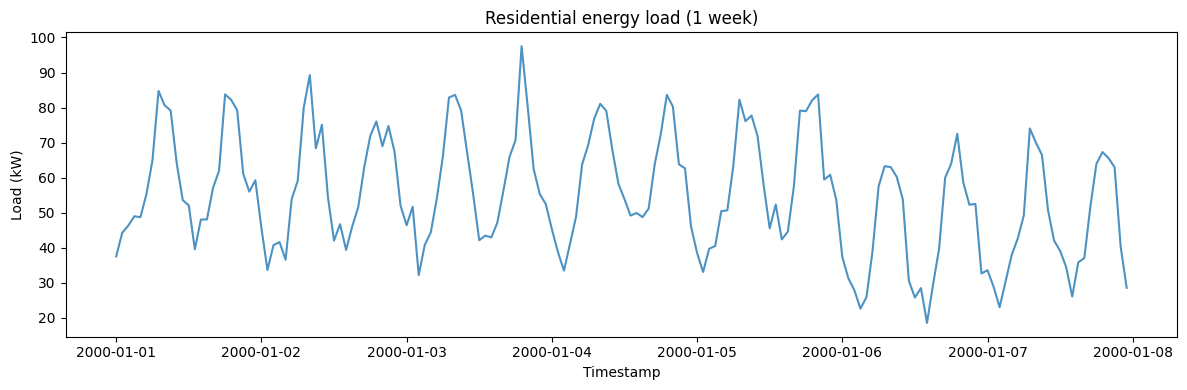

In [ ]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(residential_df["ds"].to_list(), residential_df["y"].to_list(), alpha=0.8)
ax.set_xlabel("Timestamp")
ax.set_ylabel("Load (kW)")
ax.set_title("Residential energy load (1 week)")
plt.tight_layout()
plt.show()

## 2. Commercial energy load (office building)

Office buildings show high demand during business hours and low demand at night/weekends.

In [ ]:
commercial_params = {
    "min_length": 168,
    "max_length": 168,
    "freq": "h",
    "load_type": "commercial",
    "base_load": 50.0,
    "temperature_sensitivity": 0.08,
    "seed": 42,
}
commercial_gen = EnergyLoadGenerator(engine="polars", **commercial_params)
commercial_df = commercial_gen.generate(n_series=1)
print(f"Generated {len(commercial_df)} hourly observations")
print(
    f"Statistics: Mean={commercial_df['y'].mean():.2f} kW, "
    f"Min={commercial_df['y'].min():.2f} kW, Max={commercial_df['y'].max():.2f} kW"
)
commercial_df.head(24)

Generated 168 hourly observations
Statistics: Mean=101.82 kW, Min=71.94 kW, Max=128.25 kW


unique_id,ds,y
cat,datetime[ns],f64
"""0""",2000-01-01 00:00:00,86.591504
"""0""",2000-01-01 01:00:00,93.658295
"""0""",2000-01-01 02:00:00,95.876818
"""0""",2000-01-01 03:00:00,98.244828
"""0""",2000-01-01 04:00:00,95.714007
…,…,…
"""0""",2000-01-01 19:00:00,108.620837
"""0""",2000-01-01 20:00:00,106.892316
"""0""",2000-01-01 21:00:00,96.47236


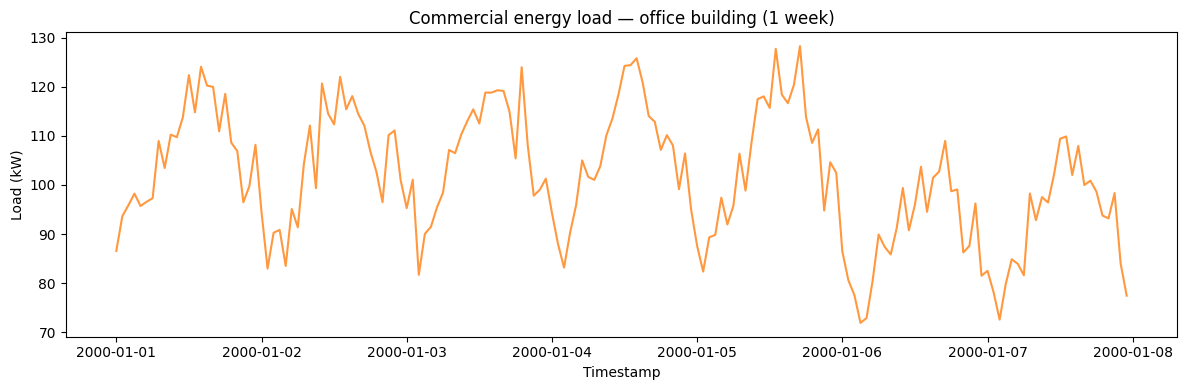

In [ ]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(commercial_df["ds"].to_list(), commercial_df["y"].to_list(), alpha=0.8, color="C1")
ax.set_xlabel("Timestamp")
ax.set_ylabel("Load (kW)")
ax.set_title("Commercial energy load — office building (1 week)")
plt.tight_layout()
plt.show()

## 3. Industrial energy load (factory)

Industrial loads are typically more constant with less temperature sensitivity.

In [ ]:
industrial_params = {
    "min_length": 168,
    "max_length": 168,
    "freq": "h",
    "load_type": "industrial",
    "base_load": 200.0,
    "temperature_sensitivity": 0.02,
    "seed": 42,
}
industrial_gen = EnergyLoadGenerator(engine="polars", **industrial_params)
industrial_df = industrial_gen.generate(n_series=1)
print(f"Generated {len(industrial_df)} hourly observations")
print(
    f"Statistics: Mean={industrial_df['y'].mean():.2f} kW, "
    f"Min={industrial_df['y'].min():.2f} kW, Max={industrial_df['y'].max():.2f} kW"
)
industrial_df.head(24)

Generated 168 hourly observations
Statistics: Mean=231.73 kW, Min=188.72 kW, Max=269.90 kW


unique_id,ds,y
cat,datetime[ns],f64
"""0""",2000-01-01 00:00:00,215.799236
"""0""",2000-01-01 01:00:00,217.076458
"""0""",2000-01-01 02:00:00,214.910692
"""0""",2000-01-01 03:00:00,214.805926
"""0""",2000-01-01 04:00:00,212.30712
…,…,…
"""0""",2000-01-01 19:00:00,239.999576
"""0""",2000-01-01 20:00:00,241.522404
"""0""",2000-01-01 21:00:00,234.366525


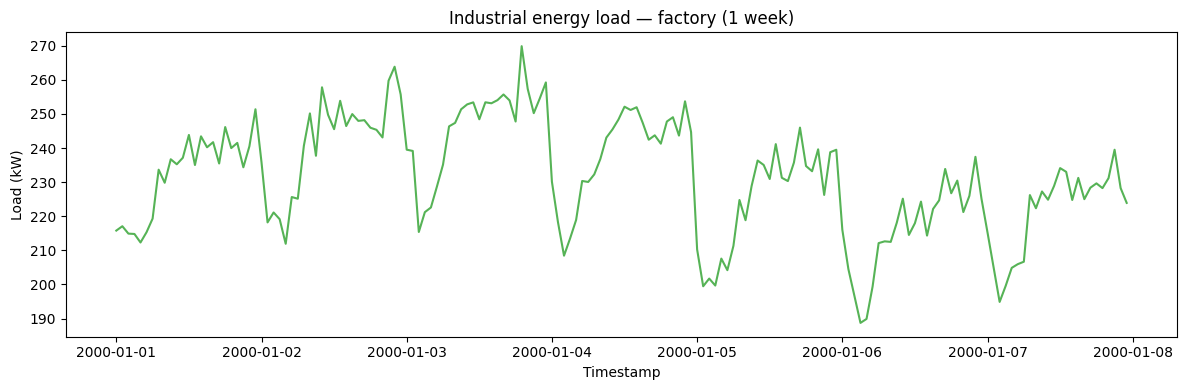

In [ ]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(industrial_df["ds"].to_list(), industrial_df["y"].to_list(), alpha=0.8, color="C2")
ax.set_xlabel("Timestamp")
ax.set_ylabel("Load (kW)")
ax.set_title("Industrial energy load — factory (1 week)")
plt.tight_layout()
plt.show()

## 4. Residential load with extreme weather

Simulate load spikes during extreme weather events like heat waves or cold snaps.

In [ ]:
extreme_weather_params = {
    "min_length": 336,
    "max_length": 336,
    "freq": "h",
    "load_type": "residential",
    "base_load": 2.0,
    "temperature_sensitivity": 0.05,
    "extreme_weather_prob": 0.1,
    "extreme_weather_impact": 2.5,
    "seed": 42,
}
extreme_gen = EnergyLoadGenerator(engine="polars", **extreme_weather_params)
extreme_df = extreme_gen.generate(n_series=1)
print(f"Generated {len(extreme_df)} hourly observations with extreme weather events")
print(
    f"Statistics: Mean={extreme_df['y'].mean():.2f} kW, "
    f"Min={extreme_df['y'].min():.2f} kW, Max={extreme_df['y'].max():.2f} kW"
)
extreme_df.head(24)

Generated 336 hourly observations with extreme weather events
Statistics: Mean=62.60 kW, Min=20.00 kW, Max=205.00 kW


unique_id,ds,y
cat,datetime[ns],f64
"""0""",2000-01-01 00:00:00,50.647778
"""0""",2000-01-01 01:00:00,33.903193
"""0""",2000-01-01 02:00:00,45.368096
"""0""",2000-01-01 03:00:00,45.453387
"""0""",2000-01-01 04:00:00,50.819034
…,…,…
"""0""",2000-01-01 19:00:00,76.554611
"""0""",2000-01-01 20:00:00,74.492959
"""0""",2000-01-01 21:00:00,65.825395


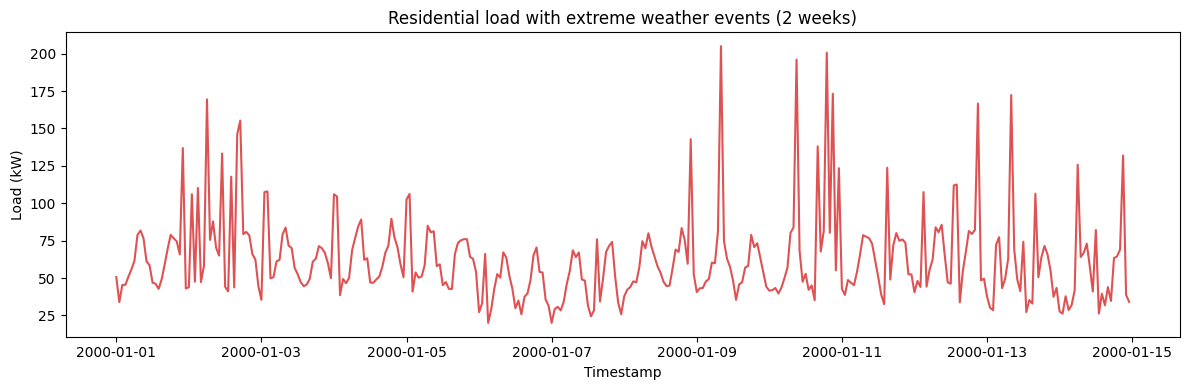

In [ ]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(extreme_df["ds"].to_list(), extreme_df["y"].to_list(), alpha=0.8, color="C3")
ax.set_xlabel("Timestamp")
ax.set_ylabel("Load (kW)")
ax.set_title("Residential load with extreme weather events (2 weeks)")
plt.tight_layout()
plt.show()

## 5. Commercial load with holiday effect

Model reduced commercial demand during holidays and weekends.

In [ ]:
holiday_params = {
    "min_length": 336,
    "max_length": 336,
    "freq": "h",
    "load_type": "commercial",
    "base_load": 50.0,
    "temperature_sensitivity": 0.08,
    "holiday_effect": 0.3,
    "seed": 42,
}
holiday_gen = EnergyLoadGenerator(engine="polars", **holiday_params)
holiday_df = holiday_gen.generate(n_series=1)
print(f"Generated {len(holiday_df)} hourly observations with holiday/weekend effects")
print(
    f"Statistics: Mean={holiday_df['y'].mean():.2f} kW, "
    f"Min={holiday_df['y'].min():.2f} kW, Max={holiday_df['y'].max():.2f} kW"
)
holiday_df.head(24)

Generated 336 hourly observations with holiday/weekend effects
Statistics: Mean=101.44 kW, Min=69.02 kW, Max=128.92 kW


unique_id,ds,y
cat,datetime[ns],f64
"""0""",2000-01-01 00:00:00,99.763688
"""0""",2000-01-01 01:00:00,83.336362
"""0""",2000-01-01 02:00:00,94.98038
"""0""",2000-01-01 03:00:00,94.749185
"""0""",2000-01-01 04:00:00,97.870654
…,…,…
"""0""",2000-01-01 19:00:00,102.963149
"""0""",2000-01-01 20:00:00,102.179314
"""0""",2000-01-01 21:00:00,101.246752


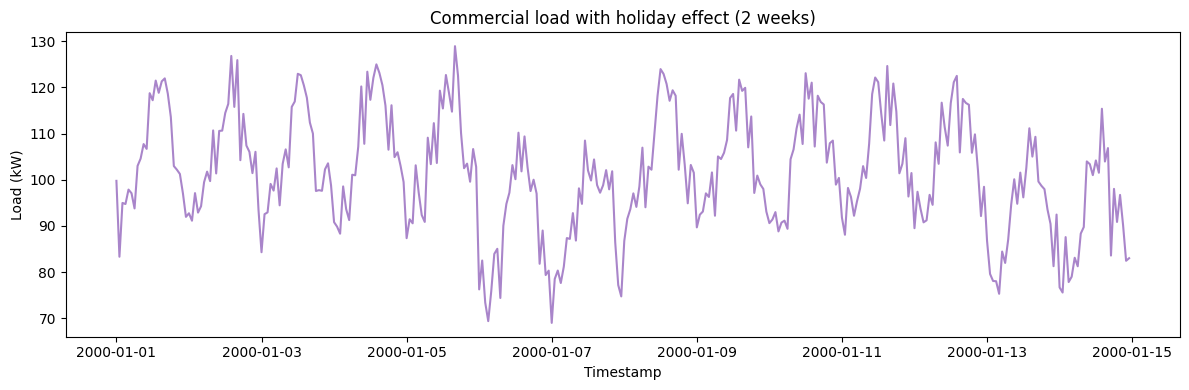

In [ ]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(holiday_df["ds"].to_list(), holiday_df["y"].to_list(), alpha=0.8, color="C4")
ax.set_xlabel("Timestamp")
ax.set_ylabel("Load (kW)")
ax.set_title("Commercial load with holiday effect (2 weeks)")
plt.tight_layout()
plt.show()

## 6. Residential load with high temperature sensitivity

Simulate a household with heavy AC/heating usage that is very sensitive to temperature changes.

In [ ]:
high_temp_params = {
    "min_length": 168,
    "max_length": 168,
    "freq": "h",
    "load_type": "residential",
    "base_load": 3.0,
    "temperature_sensitivity": 0.15,
    "seed": 42,
}
high_temp_gen = EnergyLoadGenerator(engine="polars", **high_temp_params)
high_temp_df = high_temp_gen.generate(n_series=1)
print(f"Generated {len(high_temp_df)} hourly observations with high temperature sensitivity")
print(
    f"Statistics: Mean={high_temp_df['y'].mean():.2f} kW, "
    f"Min={high_temp_df['y'].min():.2f} kW, Max={high_temp_df['y'].max():.2f} kW"
)
high_temp_df.head(24)

Generated 168 hourly observations with high temperature sensitivity
Statistics: Mean=56.94 kW, Min=20.36 kW, Max=99.35 kW


unique_id,ds,y
cat,datetime[ns],f64
"""0""",2000-01-01 00:00:00,40.255913
"""0""",2000-01-01 01:00:00,46.889278
"""0""",2000-01-01 02:00:00,48.506536
"""0""",2000-01-01 03:00:00,51.234452
"""0""",2000-01-01 04:00:00,51.012296
…,…,…
"""0""",2000-01-01 19:00:00,83.921064
"""0""",2000-01-01 20:00:00,81.484842
"""0""",2000-01-01 21:00:00,63.461836


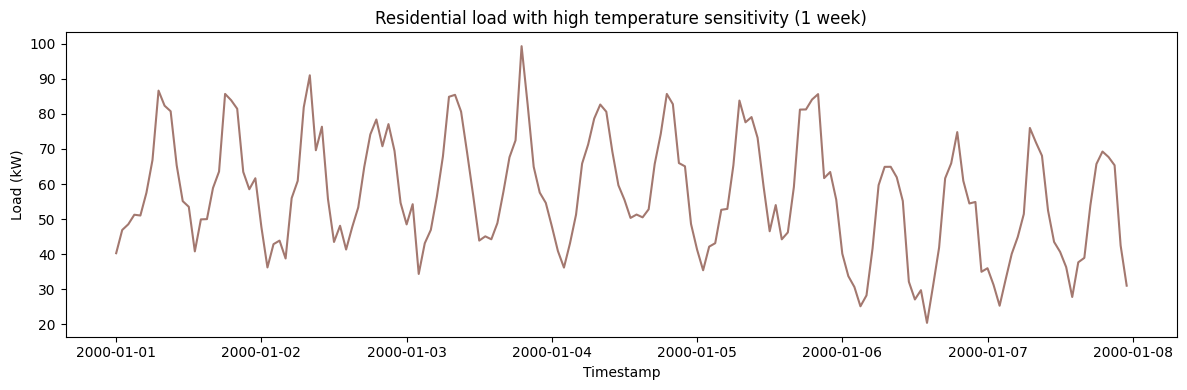

In [ ]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(high_temp_df["ds"].to_list(), high_temp_df["y"].to_list(), alpha=0.8, color="C5")
ax.set_xlabel("Timestamp")
ax.set_ylabel("Load (kW)")
ax.set_title("Residential load with high temperature sensitivity (1 week)")
plt.tight_layout()
plt.show()

## 7. Multiple residential customers

Generate load profiles for 5 residential customers simultaneously.

In [ ]:
multi_params = {
    "min_length": 168,
    "max_length": 168,
    "freq": "h",
    "load_type": "residential",
    "base_load": 2.5,
    "temperature_sensitivity": 0.05,
    "seed": 42,
}
multi_gen = EnergyLoadGenerator(engine="polars", **multi_params)
multi_df = multi_gen.generate(n_series=5)
print(f"Generated 5 residential customers with {len(multi_df)} total observations")
print(
    f"Overall Statistics: Mean={multi_df['y'].mean():.2f} kW, "
    f"Total Load={multi_df.group_by('ds').agg(pl.col('y').sum()).select('y').mean().item():.2f} kW"
)

multi_df.filter(pl.col("unique_id") == "0").head(24)

Generated 5 residential customers with 840 total observations
Overall Statistics: Mean=55.30 kW, Total Load=276.52 kW


unique_id,ds,y
cat,datetime[ns],f64
"""0""",2000-01-01 00:00:00,37.975594
"""0""",2000-01-01 01:00:00,44.725126
"""0""",2000-01-01 02:00:00,46.764535
"""0""",2000-01-01 03:00:00,49.44903
"""0""",2000-01-01 04:00:00,49.162387
…,…,…
"""0""",2000-01-01 19:00:00,82.712299
"""0""",2000-01-01 20:00:00,79.705961
"""0""",2000-01-01 21:00:00,61.551004


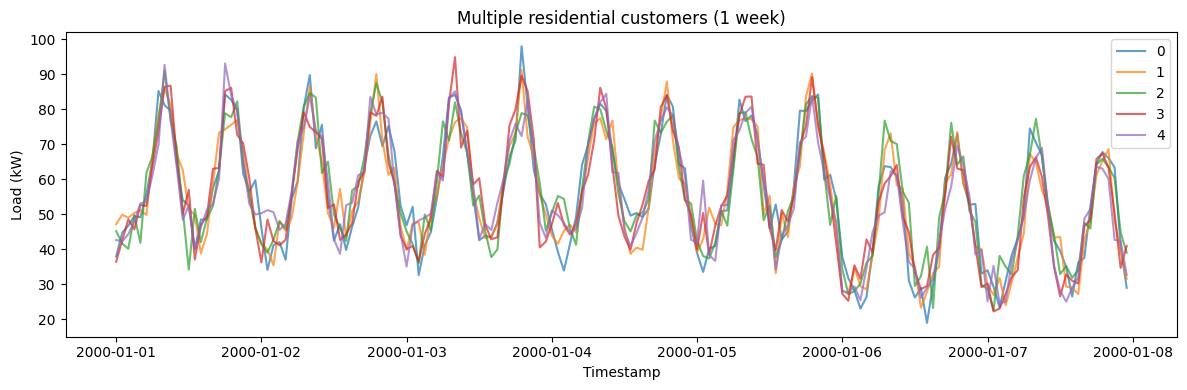

In [ ]:
fig, ax = plt.subplots(figsize=(12, 4))
for uid in multi_df["unique_id"].unique().to_list():
    series = multi_df.filter(pl.col("unique_id") == uid)
    ax.plot(series["ds"].to_list(), series["y"].to_list(), label=uid, alpha=0.7)
ax.set_xlabel("Timestamp")
ax.set_ylabel("Load (kW)")
ax.set_title("Multiple residential customers (1 week)")
ax.legend()
plt.tight_layout()
plt.show()

::: {.callout-tip}
## Related generators

- [Seasonal](../statistical/seasonal) — a single seasonal cycle.
- [SARIMA](../statistical/sarima) — seasonal ARMA dynamics.

Full parameters are in the [generator reference](https://github.com/Nixtla/synforecast/blob/main/GENERATORS.md).
:::